In [26]:
import json
import requests
import shutil
import pandas as pd
import os
import gtfs_realtime_pb2
from datetime import datetime
from collections import deque
import _utils_ as utils
import metrics

import logging
# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)


In [2]:
from google.protobuf.json_format import MessageToDict, MessageToJson
import google.protobuf
print(google.protobuf.__version__)

6.33.4


## 1 - Descargar informacion estatica del sistema




In [27]:
# Configuration
GTFS_DIRECTORY = "GTFS_Durham_TXT"
VEHICLE_POSITIONS_URL = 'https://drtonline.durhamregiontransit.com/gtfsrealtime/VehiclePositions'
TRIP_UPDATES_URL = 'https://drtonline.durhamregiontransit.com/gtfsrealtime/TripUpdates'
MAIN_ROUTE_ID = "905"
MAX_POSITION_HISTORY = 3

Explorar las columnas y tipos de datos

In [54]:
routes = pd.read_csv(os.path.join(GTFS_DIRECTORY, "routes.txt"))
print("Dimensiones de datos (filas,columnas)", routes.shape)
routes.head()

Dimensiones de datos (filas,columnas) (39, 9)


,route_long_name,route_type,route_text_color,route_color,route_url,agency_id,route_short_name,route_id,route_desc
0,Route 101,3,ffffff,006633,NaN,drt,101,101,NaN
1,Route 112,3,ffffff,006633,NaN,drt,112,112,NaN
2,Route 118,3,ffffff,006633,NaN,drt,118,118,NaN
3,Route 121,3,ffffff,006633,NaN,drt,121,121,NaN
4,Route 211,3,ffffff,006633,NaN,drt,211,211,NaN


In [29]:
shapes = pd.read_csv(os.path.join(GTFS_DIRECTORY, "shapes.txt"))
print(shapes.shape)
shapes_layer = utils.df_to_geojson(shapes, "shape_pt_lat", "shape_pt_lon", geometry_type="LineString", output_file="geojson_layers/shapes.geojson", group_by="shape_id")
shapes.head()

(213045, 5)


,shape_id,shape_pt_lat,shape_pt_lon,shape_pt_sequence,shape_dist_traveled
0,100.0.1952648908_Timetable_-_2026-01,43.832720,-79.085610,1,0.000000
1,100.0.1952648908_Timetable_-_2026-01,43.832654,-79.085581,2,7.707915
2,100.0.1952648908_Timetable_-_2026-01,43.832645,-79.085601,3,9.625517
3,100.0.1952648908_Timetable_-_2026-01,43.832590,-79.085735,4,21.991927
4,100.0.1952648908_Timetable_-_2026-01,43.832550,-79.085855,5,32.595411


In [30]:
stops = pd.read_csv(os.path.join(GTFS_DIRECTORY, "stops.txt"))
print(stops.shape)
utils.df_to_geojson(stops, "stop_lat", "stop_lon", geometry_type="Point", output_file="geojson_layers/stops.geojson", group_by=None)
stops.head(3)

(1909, 13)


,stop_desc,stop_url,stop_name,stop_lat,stop_code,stop_id,location_type,preferred,stop_timezone,stop_lon,parent_station,zone_id,wheelchair_boarding
0,NaN,NaN,Garden Northbound @ Bassett (South stop),43.903333,10,10,0,2,NaN,-78.941559,NaN,NaN,1
1,NaN,NaN,McQuay Northbound @ Dundas,43.875932,100,100,0,2,NaN,-78.961715,NaN,NaN,1
2,NaN,NaN,Glen Northbound @ Medina,43.872683,1000,1000,0,2,NaN,-78.855412,NaN,NaN,1


In [31]:
trips = pd.read_csv(os.path.join(GTFS_DIRECTORY, "trips.txt"))
print(trips.shape)
trips.head(3)

(9557, 9)


,direction_name,wheelchair_accessible,block_id,trip_id,direction_id,shape_id,route_id,service_id,trip_headsign
0,Southbound,1,a_401047_Timetable_-_2026-01,1000__401047_Timetable_-_2026-01,1,100.0.2273959138_Timetable_-_2026-01,901,Weekday_merged_94404,A - Lakeview Park
1,Southbound,1,a_401002_Timetable_-_2026-01,1001__401002_Timetable_-_2026-01,1,100.0.2273959138_Timetable_-_2026-01,901,Weekday_merged_94404,A - Lakeview Park
2,Southbound,1,a_401028_Timetable_-_2026-01,1002__401028_Timetable_-_2026-01,1,100.0.2273959138_Timetable_-_2026-01,901,Weekday_merged_94404,A - Lakeview Park


In [33]:
stop_times = pd.read_csv(os.path.join(GTFS_DIRECTORY, "stop_times.txt"))
print(stop_times.shape)
stop_times.head()

(383537, 10)


/var/folders/d4/n09rk8xd7k72h1ksgf14nmkr0000gn/T/ipykernel_50758/3282287348.py:1: DtypeWarning: Columns (0: stop_id) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv(os.path.join(GTFS_DIRECTORY, "stop_times.txt"))


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint
0,1000__401047_Timetable_-_2026-01,12:40:00,12:40:00,698,1,NaN,NaN,NaN,NaN,1.0
1,1000__401047_Timetable_-_2026-01,12:41:25,12:41:25,94189,2,NaN,NaN,NaN,NaN,NaN
2,1000__401047_Timetable_-_2026-01,12:42:25,12:42:25,706,3,NaN,NaN,NaN,NaN,NaN
3,1000__401047_Timetable_-_2026-01,12:43:25,12:43:25,707,4,NaN,NaN,NaN,NaN,NaN
4,1000__401047_Timetable_-_2026-01,12:45:51,12:45:51,710,5,NaN,NaN,NaN,NaN,NaN


## 2 - Union: Ejemplo con Paradas y Tiempos de Parada

In [34]:
print(stop_times.shape, stops.shape)
stops_times_merged = pd.merge(stop_times, stops, on='stop_id')
print("Dimensiones de tabla unida", stops_times_merged.shape)
stops_times_merged.head(3)

(383537, 10) (1909, 13)
Dimensiones de tabla unida (318001, 22)


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint,...,stop_name,stop_lat,stop_code,location_type,preferred,stop_timezone,stop_lon,parent_station,zone_id,wheelchair_boarding
0,1000__401047_Timetable_-_2026-01,12:40:00,12:40:00,698,1,NaN,NaN,NaN,NaN,1.0,...,Ontario Tech / Durham College North Campus,43.943641,698,0,1,NaN,-78.895505,NaN,NaN,1
1,1000__401047_Timetable_-_2026-01,12:41:25,12:41:25,94189,2,NaN,NaN,NaN,NaN,NaN,...,Simcoe Southbound @ Commencement,43.945083,94189,0,2,NaN,-78.892198,NaN,NaN,1
2,1000__401047_Timetable_-_2026-01,12:42:25,12:42:25,706,3,NaN,NaN,NaN,NaN,NaN,...,Simcoe Southbound @ Niagara (North stop),43.943084,706,0,2,NaN,-78.889191,NaN,NaN,1


In [ ]:
#Fetch trip updates
#logger.info("Fetching trip updates...")
#trip_updates_feed = utils.fetch_gtfs_rt_feed(TRIP_UPDATES_URL)

2026-01-25 22:36:26,937 - __main__ - INFO - Fetching trip updates...


## 3 - Información Dinámica con GET request


In [ ]:
# Fetch vehicle positions
response = requests.get(VEHICLE_POSITIONS_URL)
feed = gtfs_realtime_pb2.FeedMessage()
feed.ParseFromString(response.content)

print("Total records", len(feed.entity))
for entity in feed.entity[0:2]:
    if entity.HasField('vehicle'):
        vehicle = entity.vehicle
        position = vehicle.position
        print(f"Vehicle ID: {vehicle.vehicle.id}, Lat: {position.latitude}, Lon: {position.longitude}")

# Add timestamp to data
capture_timestamp = datetime.now()
veh_pos_dict = utils.get_veh_positions_dict(feed.entity, capture_timestamp)
veh_pos_df = pd.DataFrame(veh_pos_dict)
veh_pos_df.head()

Total records 38
Vehicle ID: 6102, Lat: 43.915931701660156, Lon: -78.91828155517578
Vehicle ID: 6112, Lat: 43.93281555175781, Lon: -78.87881469726562
Vehicle ID: 6118, Lat: 43.88793182373047, Lon: -78.87006378173828
Vehicle ID: 6125, Lat: 43.885250091552734, Lon: -79.00350189208984
Vehicle ID: 6134, Lat: 43.79264831542969, Lon: -79.1631851196289


,vehicle_id,bearing,speed,longitude,latitude,capture_timestamp,trip_id,route_id,direction_id,position_timestamp
0,6102,None,None,-78.918282,43.915932,2026-01-25T22:36:36.544685,2818__261026_Timetable_-_2026-01,905,None,2026-01-25T22:36:12
1,6112,None,None,-78.878815,43.932816,2026-01-25T22:36:36.544685,3401__462001_Timetable_-_2026-01,901,None,2026-01-25T22:36:34
2,6118,None,None,-78.870064,43.887932,2026-01-25T22:36:36.544685,914__491001_Timetable_-_2026-01,901,None,2026-01-25T22:35:49
3,6125,None,None,-79.003502,43.885250,2026-01-25T22:36:36.544685,3024__261030_Timetable_-_2026-01,916,None,2026-01-25T22:35:56
4,6134,None,None,-79.163185,43.792648,2026-01-25T22:36:36.544685,3565__463005_Timetable_-_2026-01,900,None,2026-01-25T22:35:48


In [37]:
# Fetch trip updates
response_tu = requests.get(TRIP_UPDATES_URL)
trip_updates_feed = gtfs_realtime_pb2.FeedMessage()
trip_updates_feed.ParseFromString(response_tu.content)

trip_updates_dict = utils.get_trip_updates_dict(trip_updates_feed.entity, capture_timestamp)
trip_updates_df = pd.DataFrame(trip_updates_dict)
print(f"Trip updates: {len(trip_updates_df)}")
trip_updates_df.head(3)


Trip updates: 2333


,entity_id,trip_id,route_id,direction_id,capture_timestamp,vehicle_id,stop_id,stop_sequence,arrival_delay,arrival_time,departure_delay,departure_time
0,3566__462004_Timetable_-_2026-01,3566__462004_Timetable_-_2026-01,900,None,2026-01-25T22:36:36.544685,8624,1593,32,None,2026-01-25T22:35:39,None,2026-01-25T22:35:39
1,3566__462004_Timetable_-_2026-01,3566__462004_Timetable_-_2026-01,900,None,2026-01-25T22:36:36.544685,8624,1594,33,None,2026-01-25T22:35:39,None,2026-01-25T22:35:39
2,3566__462004_Timetable_-_2026-01,3566__462004_Timetable_-_2026-01,900,None,2026-01-25T22:36:36.544685,8624,1595,34,None,2026-01-25T22:36:36,None,2026-01-25T22:36:36


## 4 - Time-Series Tracking (Last 3 Positions)

In [39]:
# Track position history (last 3 positions per vehicle)
POSITION_HISTORY_FILE = "geojson_layers/position_history.json"

# Load existing history
position_history = {}
if os.path.exists(POSITION_HISTORY_FILE):
    with open(POSITION_HISTORY_FILE, 'r') as f:
        data = json.load(f)
        for vehicle_id, positions in data.items():
            position_history[vehicle_id] = deque(positions[-MAX_POSITION_HISTORY:], maxlen=MAX_POSITION_HISTORY)

# Update history with current positions
for _, row in veh_pos_df.iterrows():
    vehicle_id = str(row['vehicle_id'])
    position_record = {
        'latitude': row['latitude'],
        'longitude': row['longitude'],
        'timestamp': row['capture_timestamp']
    }
    if vehicle_id not in position_history:
        position_history[vehicle_id] = deque(maxlen=MAX_POSITION_HISTORY)
    position_history[vehicle_id].append(position_record)

# Save history
with open(POSITION_HISTORY_FILE, 'w') as f:
    data = {vid: list(positions) for vid, positions in position_history.items()}
    json.dump(data, f, indent=2)

# Create DataFrame with all positions
all_positions = []
for vehicle_id, positions in position_history.items():
    for pos in positions:
        pos['vehicle_id'] = vehicle_id
        all_positions.append(pos)
position_history_df = pd.DataFrame(all_positions)
print(f"Position history: {len(position_history_df)} records")

Position history: 176 records


# Section 4: Enhanced Visualizations

Create interactive maps with vehicle trails, stops, and route shapes.

In [42]:
# Calculate speeds from position history
if not position_history_df.empty:
    # Calculate time deltas
    position_history_df = utils.calculate_time_deltas(
        position_history_df,
        time_col='timestamp'
    )
    
    # Calculate speeds for each vehicle
    vehicle_speeds = {}
    for vehicle_id in position_history_df['vehicle_id'].unique():
        speed = utils.calculate_speed_from_positions(
            position_history_df,
            vehicle_id,
            time_col='timestamp'
        )
        if speed is not None:
            vehicle_speeds[vehicle_id] = {
                'calculated_speed_mps': speed,
                'calculated_speed_kmh': speed * 3.6
            }
    
    logger.info(f"Calculated speeds for {len(vehicle_speeds)} vehicles")
    
    # Add calculated speeds to current vehicle positions
    if not veh_pos_df.empty:
        veh_pos_df['calculated_speed_kmh'] = veh_pos_df['vehicle_id'].map(
            lambda x: vehicle_speeds.get(str(x), {}).get('calculated_speed_kmh', None)
        )
        
        # Detect traffic conditions based on speed
        veh_pos_df['traffic_condition'] = pd.cut(
            veh_pos_df['calculated_speed_kmh'],
            bins=[0, 10, 30, 60, float('inf')],
            labels=['Heavy Traffic', 'Moderate Traffic', 'Light Traffic', 'Free Flow'],
            include_lowest=True
        )
        
        display(veh_pos_df[['vehicle_id', 'calculated_speed_kmh', 'traffic_condition']].head())
else:
    logger.warning("Cannot calculate speeds - insufficient position history")

2026-01-25 22:38:40,489 - __main__ - INFO - Calculated speeds for 18 vehicles


,vehicle_id,calculated_speed_kmh,traffic_condition
0,6102,None,None
1,6112,None,None
2,6118,None,None
3,6125,None,None
4,6134,None,None


In [43]:
# Export GeoJSON
veh_pos_geojson = utils.get_veh_positions_geojson(feed.entity)

directory = "geojson_layers"
current_path = os.path.join(directory, "vehicle_positions.geojson")
previous_path = os.path.join(directory, "vehicle_positions_previous.geojson")

# Move current to previous if exists
if os.path.exists(current_path):
    shutil.move(current_path, previous_path)

# Save new GeoJSON
with open(current_path, "w") as f:
    json.dump(veh_pos_geojson, f, indent=2)

veh_pos_df

,vehicle_id,bearing,speed,longitude,latitude,capture_timestamp,trip_id,route_id,direction_id,position_timestamp,calculated_speed_kmh,traffic_condition
0,6102,None,None,-78.918282,43.915932,2026-01-25T22:36:36.544685,2818__261026_Timetable_-_2026-01,905,None,2026-01-25T22:36:12,None,None
1,6112,None,None,-78.878815,43.932816,2026-01-25T22:36:36.544685,3401__462001_Timetable_-_2026-01,901,None,2026-01-25T22:36:34,None,None
2,6118,None,None,-78.870064,43.887932,2026-01-25T22:36:36.544685,914__491001_Timetable_-_2026-01,901,None,2026-01-25T22:35:49,None,None
3,6125,None,None,-79.003502,43.885250,2026-01-25T22:36:36.544685,3024__261030_Timetable_-_2026-01,916,None,2026-01-25T22:35:56,None,None
4,6134,None,None,-79.163185,43.792648,2026-01-25T22:36:36.544685,3565__463005_Timetable_-_2026-01,900,None,2026-01-25T22:35:48,None,None


## 6 - Crear mapa de posición previa y actual de vehículos

2026-01-25 22:27:27,916 - matplotlib.axes._base - WARNING - Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


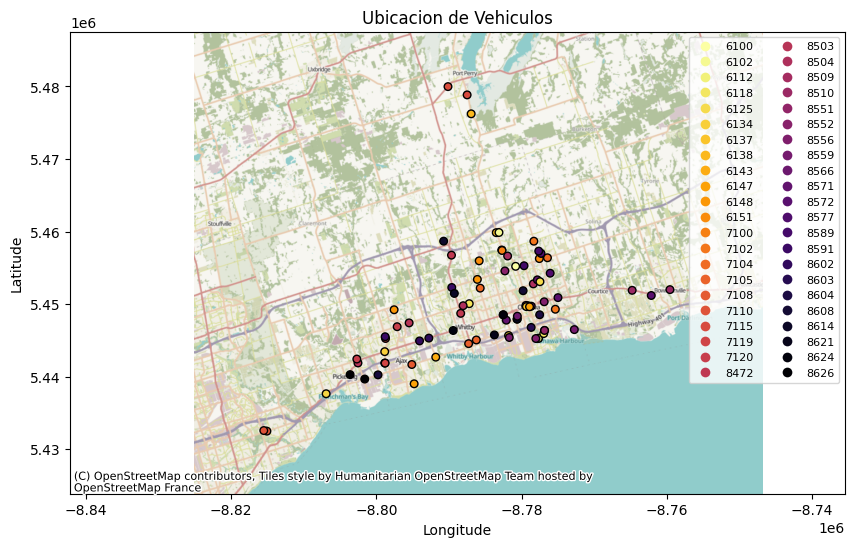

{'vehicles_with_connections': 0,
 'vehicles_with_one_pair': 0,
 'total_connections': 0}

In [16]:
# Load previous positions for comparison
try:
    with open(previous_path, 'r') as f:
        prev_geojson = json.load(f)
        prev_positions = []
        for feature in prev_geojson['features']:
            props = feature['properties']
            prev_positions.append({
                'vehicle_id': props.get('vehicle_id'),
                'latitude': feature['geometry']['coordinates'][1],
                'longitude': feature['geometry']['coordinates'][0]
            })
        prev_pos_df = pd.DataFrame(prev_positions)
except:
    prev_pos_df = pd.DataFrame()

utils.plot_map([veh_pos_df, prev_pos_df], "longitude", "latitude", 'vehicle_id', 'inferno_r', 'Ubicacion de Vehiculos')

## 6.5 - Mapa de Formas de Rutas y Paradas

In [ ]:
# Plot route shapes and stops
# Load trips if not already loaded
if 'trips' not in locals():
    trips = pd.read_csv(os.path.join(GTFS_DIRECTORY, "trips.txt"))

# Load routes if not already loaded  
if 'routes' not in locals():
    routes = pd.read_csv(os.path.join(GTFS_DIRECTORY, "routes.txt"))

# Load stops if not already loaded
if 'stops' not in locals():
    stops = pd.read_csv(os.path.join(GTFS_DIRECTORY, "stops.txt"))

# Plot all routes or filter by main route
utils.plot_route_shapes_and_stops(
    shapes_df=shapes,
    stops_df=stops,
    route_id=MAIN_ROUTE_ID,  # Filter by main route
    trips_df=trips,
    routes_df=routes,
    title=f"Route Shapes and Stops - Route {MAIN_ROUTE_ID}",
    figsize=(14, 10)
)

## 7 - Métricas de Performance

In [44]:
# On-Time Performance
if not trip_updates_df.empty and not stop_times.empty:
    otp_metrics = metrics.calculate_on_time_performance(trip_updates_df, stop_times, stops, on_time_threshold_minutes=2)
    if otp_metrics:
        print(f"OTP: {otp_metrics.get('otp_percentage', 0):.2f}%")
        print(f"Average Delay: {otp_metrics.get('average_delay_minutes', 0):.2f} minutes")

2026-01-25 22:39:32,899 - metrics - WARNING - No data available after processing delays


In [45]:
# Headway Analysis
if not veh_pos_df.empty and not trips.empty:
    headway_metrics = metrics.calculate_headways(veh_pos_df, trips, route_id=MAIN_ROUTE_ID)
    if headway_metrics:
        print(f"Average Headway: {headway_metrics.get('average_headway_minutes', 0):.2f} minutes")
        print(f"Bunching Events: {headway_metrics.get('bunching_events', 0)}")

2026-01-25 22:39:34,284 - metrics - WARNING - No route_id column found after merge - trip IDs may not match between static and real-time data


In [46]:
# Service Frequency
if not veh_pos_df.empty and not trips.empty:
    frequency_metrics = metrics.calculate_service_frequency(veh_pos_df, trips, time_window_minutes=60)
    if frequency_metrics:
        print(f"Overall Frequency: {frequency_metrics.get('overall_frequency_per_hour', 0):.2f} vehicles/hour")

2026-01-25 22:39:44,919 - metrics - WARNING - No route_id column found after merge - trip IDs may not match


In [ ]:
# Speed and Travel Time
if not position_history_df.empty:
    speed_metrics = metrics.calculate_speed_and_travel_time(position_history_df, shapes_df=shapes, trips_df=trips)
    if speed_metrics:
        print(f"Average Speed: {speed_metrics.get('average_speed_kmh', 0):.2f} km/h")
        print(f"Median Speed: {speed_metrics.get('median_speed_kmh', 0):.2f} km/h")

In [ ]:
# Spatial Coverage
if not veh_pos_df.empty and not routes.empty:
    coverage_metrics = metrics.calculate_spatial_coverage(veh_pos_df, routes, shapes_df=None, stops_df=stops)
    if coverage_metrics and 'route_coverage' in coverage_metrics:
        rc = coverage_metrics['route_coverage']
        print(f"Route Coverage: {rc.get('coverage_percentage', 0):.2f}%")

In [47]:
ON_TIME_THRESHOLD_MINUTES = 5
# Calculate On-Time Performance
if not trip_updates_df.empty and not stop_times.empty:
    otp_metrics = metrics.calculate_on_time_performance(
        trip_updates_df,
        stop_times,
        stops,
        on_time_threshold_minutes=ON_TIME_THRESHOLD_MINUTES
    )
    
    if otp_metrics:
        logger.info("On-Time Performance Metrics:")
        logger.info(f"  OTP Percentage: {otp_metrics.get('otp_percentage', 0):.2f}%")
        logger.info(f"  Average Delay: {otp_metrics.get('average_delay_minutes', 0):.2f} minutes")
        logger.info(f"  On-Time Stops: {otp_metrics.get('on_time_stops', 0)}/{otp_metrics.get('total_stops', 0)}")
        
        display(pd.DataFrame([otp_metrics]).T.rename(columns={0: 'Value'}))
    else:
        logger.warning("Could not calculate OTP metrics")
else:
    logger.warning("Insufficient data for OTP calculation")

2026-01-25 22:39:48,984 - metrics - WARNING - No data available after processing delays
2026-01-25 22:39:49,003 - __main__ - WARNING - Could not calculate OTP metrics


In [48]:
# Calculate Headway Analysis
if not veh_pos_df.empty and not trips.empty:
    headway_metrics = metrics.calculate_headways(
        veh_pos_df,
        trips,
        route_id=MAIN_ROUTE_ID if MAIN_ROUTE_ID else None
    )
    
    if headway_metrics:
        logger.info("Headway Metrics:")
        logger.info(f"  Average Headway: {headway_metrics.get('average_headway_minutes', 0):.2f} minutes")
        logger.info(f"  Bunching Events: {headway_metrics.get('bunching_events', 0)}")
        logger.info(f"  Gap Events: {headway_metrics.get('gap_events', 0)}")
        
        display(pd.DataFrame([headway_metrics]).T.rename(columns={0: 'Value'}))
    else:
        logger.warning("Could not calculate headway metrics")
else:
    logger.warning("Insufficient data for headway calculation")

2026-01-25 22:39:49,488 - metrics - WARNING - No route_id column found after merge - trip IDs may not match between static and real-time data
2026-01-25 22:39:49,496 - __main__ - WARNING - Could not calculate headway metrics


In [49]:
# Calculate Service Frequency
if not veh_pos_df.empty and not trips.empty:
    frequency_metrics = metrics.calculate_service_frequency(
        veh_pos_df,
        trips,
        time_window_minutes=SERVICE_FREQUENCY_WINDOW_MINUTES
    )
    
    if frequency_metrics:
        logger.info("Service Frequency Metrics:")
        logger.info(f"  Overall Frequency: {frequency_metrics.get('overall_frequency_per_hour', 0):.2f} vehicles/hour")
        logger.info(f"  Routes with Service: {frequency_metrics.get('total_routes_with_service', 0)}")
        
        if 'frequency_by_route' in frequency_metrics:
            freq_df = pd.DataFrame(frequency_metrics['frequency_by_route']).T
            display(freq_df)
    else:
        logger.warning("Could not calculate frequency metrics")
else:
    logger.warning("Insufficient data for frequency calculation")

2026-01-25 22:39:50,203 - metrics - WARNING - No route_id column found after merge - trip IDs may not match
2026-01-25 22:39:50,204 - __main__ - WARNING - Could not calculate frequency metrics


In [50]:
# Calculate Speed and Travel Time Analysis
if not position_history_df.empty:
    speed_metrics = metrics.calculate_speed_and_travel_time(
        position_history_df,
        shapes_df=shapes if not shapes.empty else None,
        trips_df=trips if not trips.empty else None
    )
    
    if speed_metrics:
        logger.info("Speed and Travel Time Metrics:")
        logger.info(f"  Average Speed: {speed_metrics.get('average_speed_kmh', 0):.2f} km/h")
        logger.info(f"  Median Speed: {speed_metrics.get('median_speed_kmh', 0):.2f} km/h")
        logger.info(f"  Max Speed: {speed_metrics.get('max_speed_kmh', 0):.2f} km/h")
        
        display(pd.DataFrame([{k: v for k, v in speed_metrics.items() if k not in ['speed_by_vehicle', 'speed_by_route']}]).T.rename(columns={0: 'Value'}))
    else:
        logger.warning("Could not calculate speed metrics")
else:
    logger.warning("Insufficient position history for speed calculation")

2026-01-25 22:39:51,015 - metrics - WARNING - No timestamp column found for speed calculation
2026-01-25 22:39:51,016 - __main__ - WARNING - Could not calculate speed metrics


In [51]:
# Calculate Spatial Coverage Metrics
if not veh_pos_df.empty and not routes.empty:
    coverage_metrics = metrics.calculate_spatial_coverage(
        veh_pos_df,
        routes,
        shapes_df= None,
        stops_df=stops if not stops.empty else None
    )
    
    if coverage_metrics:
        logger.info("Spatial Coverage Metrics:")
        if 'route_coverage' in coverage_metrics:
            rc = coverage_metrics['route_coverage']
            logger.info(f"  Route Coverage: {rc.get('coverage_percentage', 0):.2f}% ({rc.get('active_routes', 0)}/{rc.get('total_routes', 0)})")
        
        if 'vehicles_per_route' in coverage_metrics:
            logger.info(f"  Average Vehicles per Route: {coverage_metrics.get('average_vehicles_per_route', 0):.2f}")
        
        # Display as multi-index DataFrame
        coverage_df = utils.dict_to_multiindex_df(coverage_metrics)
        display(coverage_df)
        #display(pd.DataFrame([coverage_metrics]).T.rename(columns={0: 'Value'}))
    else:
        logger.warning("Could not calculate coverage metrics")
else:
    logger.warning("Insufficient data for coverage calculation")

2026-01-25 22:39:51,707 - __main__ - INFO - Spatial Coverage Metrics:
2026-01-25 22:39:51,708 - __main__ - INFO -   Route Coverage: 33.33% (13/39)
2026-01-25 22:39:51,710 - __main__ - INFO -   Average Vehicles per Route: 2.92


Value
route_coverage             active_routes                                                       13
                           total_routes                                                        39
                           coverage_percentage                                          33.333333
                           active_route_ids     [905, 901, 916, 900, 902, 917, 224, 915, 409, ...
stop_coverage              total_stops                                                       1909
                           note                 Distance-based coverage calculation requires s...
vehicles_per_route         224                                                                  1
                           302                                                                  1
                           405                                                                  1
                           407                                                                  2
                           409                                                                  1
                           410                                                                  2
                           900                                                                  6
                           901                                                                  3
                           902                                                                  4
                           905                                                                  5
                           915                                                                  3
                           916                                                                  4
                           917                                                                  5
average_vehicles_per_route                                                               2.923077
geographic_bounds          min_lat                                                      43.792648
                           max_lat                                                      44.111683
                           min_lon                                                     -79.163185
                           max_lon                                                     -78.684952

# Section 7: Summary and Data Quality Report

In [25]:
# Generate summary report
logger.info("=" * 60)
logger.info("DATA COLLECTION SUMMARY")
logger.info("=" * 60)
logger.info(f"Capture Timestamp: {capture_timestamp.isoformat()}")
logger.info(f"Vehicle Positions: {len(veh_pos_df)}")
logger.info(f"Trip Updates: {len(trip_updates_df)}")
logger.info(f"Position History Records: {len(position_history_df)}")
logger.info(f"Unique Vehicles Tracked: {len(position_history)}")

# Data quality checks
if not veh_pos_df.empty:
    missing_coords = veh_pos_df[['latitude', 'longitude']].isnull().sum()
    logger.info(f"Missing Coordinates: {missing_coords.sum()}")
    
    if 'route_id' in veh_pos_df.columns:
        routes_with_vehicles = veh_pos_df['route_id'].nunique()
        logger.info(f"Routes with Active Vehicles: {routes_with_vehicles}")

logger.info("=" * 60)

2026-01-25 22:28:09,592 - __main__ - INFO - ============================================================
2026-01-25 22:28:09,594 - __main__ - INFO - DATA COLLECTION SUMMARY
2026-01-25 22:28:09,595 - __main__ - INFO - ============================================================
2026-01-25 22:28:09,595 - __main__ - INFO - Capture Timestamp: 2026-01-25T22:27:13.785796
2026-01-25 22:28:09,596 - __main__ - INFO - Vehicle Positions: 40
2026-01-25 22:28:09,597 - __main__ - INFO - Trip Updates: 2503
2026-01-25 22:28:09,598 - __main__ - INFO - Position History Records: 176
2026-01-25 22:28:09,598 - __main__ - INFO - Unique Vehicles Tracked: 59
2026-01-25 22:28:09,600 - __main__ - INFO - Missing Coordinates: 0
2026-01-25 22:28:09,601 - __main__ - INFO - Routes with Active Vehicles: 14
2026-01-25 22:28:09,602 - __main__ - INFO - ============================================================
